In [23]:
import importlib
import pandas as pd
import os
import xgboost as xgb
import json
import numpy as np
from pathlib import Path
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score
import utils.helpers as utils_helpers

os.getcwd()

'/home/yvan/Desktop/FCKcat/notebooks'

In [24]:
df_kcat_all = pd.read_pickle(Path("..") / "data" / "datasets" / "df_kcat_final.pkl")


In [25]:
group_sizes = df_kcat_all.groupby("Identifier")["Identifier"].transform("size")
df_kcat_all = df_kcat_all[group_sizes > 1].copy()

In [26]:
print("Wildtype:", df_kcat_all[df_kcat_all['Type'] == 'wildtype']['Sequence_new'].nunique())
print("Mutant:", df_kcat_all[df_kcat_all['Type'] == 'mutant']['Sequence_new'].nunique())

Wildtype: 1085
Mutant: 5926


In [27]:
df_kcat_all.value_counts('Type')

Type
mutant      6898
wildtype    1391
Name: count, dtype: int64

In [28]:
df_kcat_all_mutant = df_kcat_all[df_kcat_all['Type'] == 'mutant'].copy()

In [29]:
df_kcat_all_mutant['Mutation_type'].value_counts()

Mutation_type
substitution    6787
deletion         103
insertion          4
addition           2
deletion+sub       2
Name: count, dtype: int64

## 1. Variance partitioning using random-intercept linear mixed-effects models 

1.1 Group effect

In [30]:
group_sizes = df_kcat_all.groupby("Identifier")["Identifier"].transform("size")
df_kcat_all = df_kcat_all[group_sizes > 1].copy()

df = df_kcat_all[['Identifier', 'geom_kcat_log10']].dropna().copy()
df['Identifier'] = df['Identifier'].astype(str)

model = smf.mixedlm("geom_kcat_log10 ~ 1", data=df, groups=df["Identifier"])
result = model.fit(reml=True)

group_var = result.cov_re.iloc[0, 0]
resid_var = result.scale
icc = group_var / (group_var + resid_var)

print(result.summary())
print(f"Group variance: {group_var:.4f}")
print(f"Residual variance: {resid_var:.4f}")
print(f"ICC: {icc:.4f}")
print(f"Percent variance due to group: {100*icc:.2f}%")

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: geom_kcat_log10
No. Observations: 8289    Method:             REML           
No. Groups:       1526    Scale:              0.8220         
Min. group size:  2       Log-Likelihood:     -12654.6844    
Max. group size:  81      Converged:          Yes            
Mean group size:  5.4                                        
---------------------------------------------------------------
             Coef.   Std.Err.     z     P>|z|   [0.025   0.975]
---------------------------------------------------------------
Intercept    0.278      0.035   8.008   0.000    0.210    0.345
Group Var    1.603      0.080                                  

Group variance: 1.6032
Residual variance: 0.8220
ICC: 0.6611
Percent variance due to group: 66.11%


1.2 Direction effect

In [31]:
df_kcat_all = utils_helpers.compute_delta_kcat(df_kcat_all)

In [32]:
df_kcat_delta = df_kcat_all.copy()
df_kcat_delta["Type_clean"] = df_kcat_delta["Type"].astype(str).str.strip().str.lower()

df_kcat_delta = df_kcat_delta[
    (df_kcat_delta["Type_clean"] != "wildtype") &
    (df_kcat_delta["delta"].notna())
].copy()

print(df_kcat_delta["delta"].dtype)
print(df_kcat_delta[["Identifier", "Type", "delta"]].head())

float64
   Identifier    Type     delta
0           0  mutant  0.055101
1           0  mutant -0.037591
2           0  mutant  0.385887
4           4  mutant -0.654388
8          15  mutant -0.284103


In [33]:
model_delta = smf.mixedlm(
    "delta ~ 1",
    data=df_kcat_delta,
    groups=df_kcat_delta["Identifier"]
)

result_delta = model_delta.fit(reml=True)

group_var = result_delta.cov_re.iloc[0, 0]
resid_var = result_delta.scale
icc = group_var / (group_var + resid_var)

print(result_delta.summary())
print("Group variance:", group_var)
print("Residual variance:", resid_var)
print("ICC:", icc)
print("Percent variance due to group:", 100 * icc)

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: delta     
No. Observations: 6333    Method:             REML      
No. Groups:       1391    Scale:              0.7479    
Min. group size:  1       Log-Likelihood:     -9081.4004
Max. group size:  80      Converged:          Yes       
Mean group size:  4.6                                   
--------------------------------------------------------
             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept    -0.760    0.028 -27.527 0.000 -0.814 -0.706
Group Var     0.759    0.051                            

Group variance: 0.7586901953901853
Residual variance: 0.7479375627535854
ICC: 0.503568443691044
Percent variance due to group: 50.3568443691044


## 2. Reproduction of Figure 1

In [34]:
df_test_pairs = pd.read_pickle(Path("..") / "data" / "datasets" / "df_test_pairs.pkl")
df_train_pairs = pd.read_pickle(Path("..") / "data" / "datasets" / "df_train_pairs.pkl")

df_test_unpaired = utils_helpers.unpack_pairs_df(df_test_pairs)
df_train_unpaired = utils_helpers.unpack_pairs_df(df_train_pairs)

In [35]:
df_test_unpaired = utils_helpers.compute_average_kcat(df_test_unpaired, df_train_unpaired)
df_test_pairs = utils_helpers.compute_paired_delta_from_training(df_test_pairs, df_test_unpaired)


In [36]:

df_test_ordered = utils_helpers.order_pairs_mutant_first(df_test_pairs)

df_test_ordered['delta'] = df_test_ordered['log10kcat'].apply(lambda x: x[0] - x[1])
df_test_ordered_mw = df_test_ordered[df_test_ordered['Type'].apply(lambda x: x == ['mutant', 'wildtype'])]

In [37]:
df_kcat_all, avg_delta_dict = utils_helpers.compute_group_average_delta(df_kcat_all)
avg_delta_dict = {k: v for k, v in avg_delta_dict.items() if pd.notna(v)}

In [38]:
df_test_unpaired_mutant = df_test_unpaired[df_test_unpaired['Type'] == 'mutant']


Bad key text.latex.preview in file utils/CCB_plot_style_0v4.mplstyle, line 55 ('text.latex.preview  : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file utils/CCB_plot_style_0v4.mplstyle, line 63 ('mathtext.fallback_to_cm : True ## When True, use symbols from the Computer Modern fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


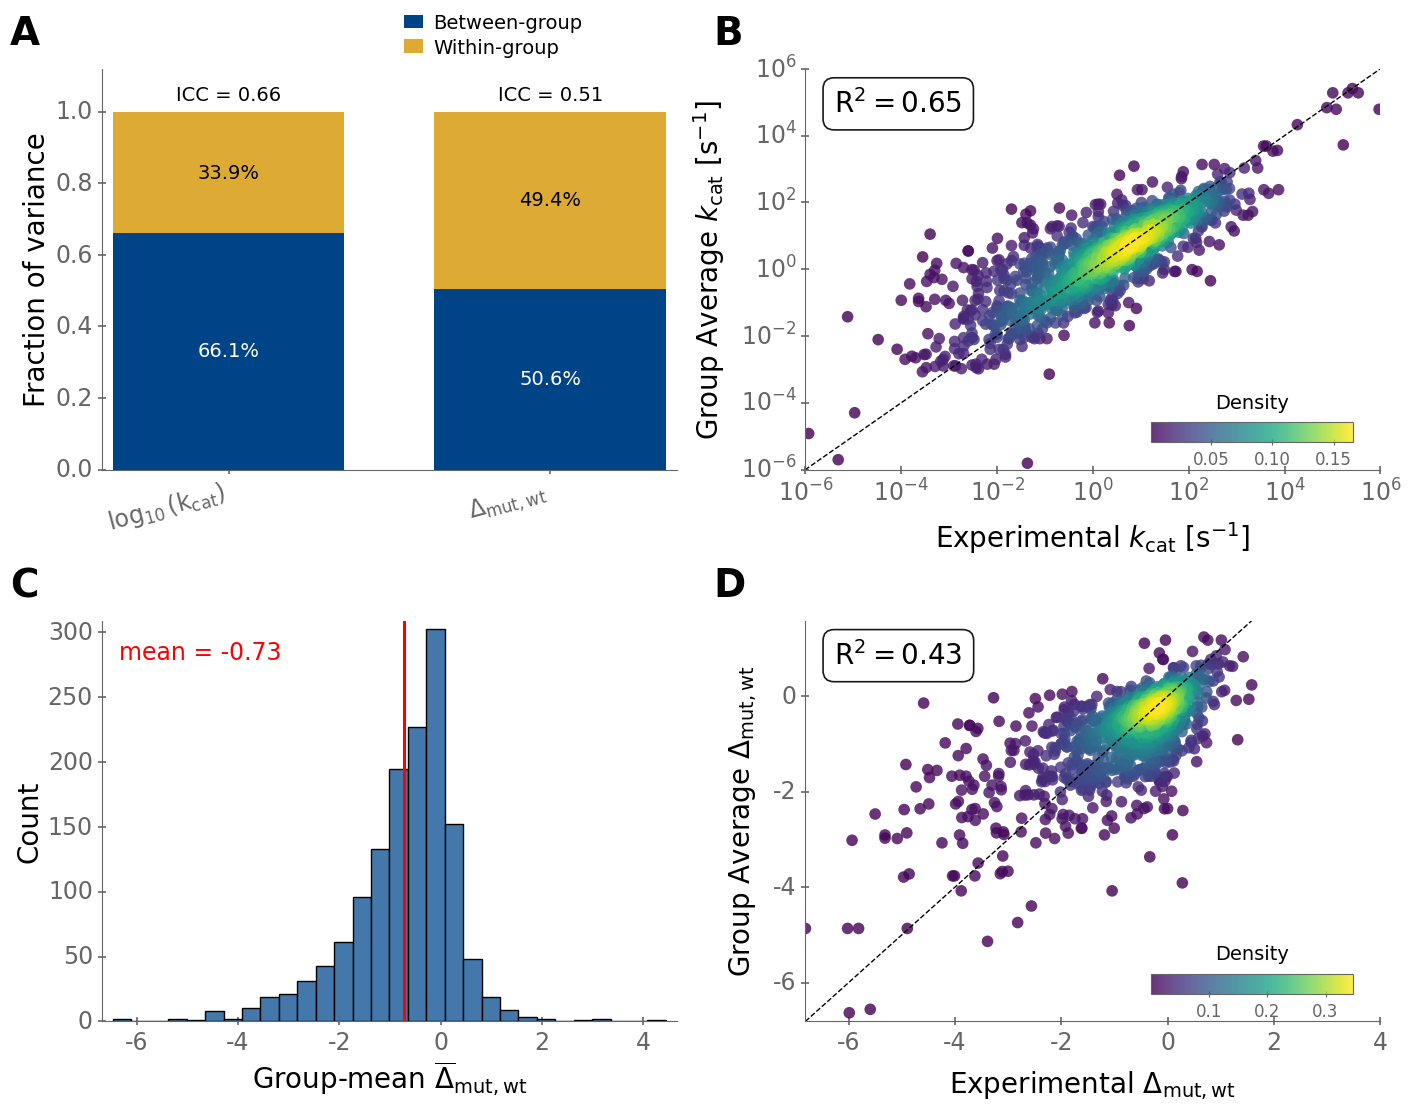

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter

plt.style.use(Path("utils") / "CCB_plot_style_0v4.mplstyle")

LABEL_FS = 20
TITLE_FS = 18
TICK_FS  = 17
ANNOT_FS = 23
CBAR_FS  = 16
BAR_FS   = 14

def _pow10_formatter_from_log10(val, pos):
    """Format log10(kcat) axis ticks as powers of 10."""
    if not np.isfinite(val):
        return ""

    exponent = int(np.round(val))
    if np.isclose(val, exponent, atol=1e-6):
        return rf"$10^{{{exponent}}}$"
    return ""

fig = plt.figure(figsize=(14, 11), constrained_layout=True)
gs  = gridspec.GridSpec(2, 2, figure=fig)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

## A. Variance decomposition
labels_var    = [r'$\log_{10}(k_{\mathrm{cat}})$',
                 r'$\Delta_{\mathrm{mut,wt}}$']
between_group = np.array([1.6032, 0.7662070490919531])
within_group  = np.array([0.8220, 0.7490436048236873])

utils_helpers.plot_variance_decomposition(
    between_group,
    within_group,
    labels_var,
    ax=ax_a,
    fontsize=BAR_FS
)

ax_a.set_ylabel('Fraction of variance', fontsize=LABEL_FS)
ax_a.set_xticklabels(ax_a.get_xticklabels(), rotation=15, ha='right', fontsize=BAR_FS)
ax_a.legend(
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.68, 1.01),
    ncol=1,
    fontsize=BAR_FS
)

## B. Density scatter
p_b = utils_helpers._scatter_panel(
    ax_b,
    df_test_unpaired_mutant['log10kcat'],
    df_test_unpaired_mutant['average_kcat_group'],
    title="",
    x_label=r"Experimental $\mathit{k}_{\mathrm{cat}}$ [s$^{-1}$]",
    y_label=r"Group Average $\mathit{k}_{\mathrm{cat}}$ [s$^{-1}$]",
)

ax_b.set_xlim(-6, 6)
ax_b.set_ylim(-6, 6)

ax_b.set_xticks(np.arange(-6, 7, 2))
ax_b.set_yticks(np.arange(-6, 7, 2))

ax_b.xaxis.set_major_formatter(FuncFormatter(_pow10_formatter_from_log10))
ax_b.yaxis.set_major_formatter(FuncFormatter(_pow10_formatter_from_log10))

ax_b.xaxis.label.set_size(LABEL_FS)
ax_b.yaxis.label.set_size(LABEL_FS)
ax_b.title.set_size(TITLE_FS)

## C. Histogram of group-level mean delta
avg_delta_vals = pd.Series(avg_delta_dict, dtype=float)
avg_delta_vals = pd.to_numeric(avg_delta_vals, errors='coerce')
avg_delta_vals = avg_delta_vals[np.isfinite(avg_delta_vals)]

ax_c.hist(avg_delta_vals, bins=30, edgecolor='black')
ax_c.set_xlabel(r"Group-mean $\overline{\Delta}_{\mathrm{mut,wt}}$", fontsize=LABEL_FS)
ax_c.set_ylabel("Count", fontsize=LABEL_FS)

mean_delta = avg_delta_vals.mean()
ax_c.axvline(mean_delta, color='red', linestyle='-', linewidth=2.2)

ax_c.text(
    0.03, 0.95,
    rf"mean = {mean_delta:.2f}",
    transform=ax_c.transAxes,
    color='red',
    fontsize=TICK_FS,
    ha='left',
    va='top',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2.5)
)

## D. Density scatter
p_d = utils_helpers._scatter_panel(
    ax_d,
    df_test_ordered_mw['delta'],
    df_test_ordered_mw['average_delta'],
    title="",
    x_label=r"Experimental $\Delta_{\mathrm{mut,wt}}$",
    y_label=r"Group Average $\Delta_{\mathrm{mut,wt}}$",
)

ax_d.xaxis.label.set_size(LABEL_FS)
ax_d.yaxis.label.set_size(LABEL_FS)
ax_d.title.set_size(TITLE_FS)

xmin_d, xmax_d = ax_d.get_xlim()
ax_d.set_xlim(xmin_d, 4)

# Formatting ticks
for i, ax in enumerate([ax_a, ax_b, ax_c, ax_d]):
    ax.tick_params(axis="both", which="major", labelsize=TICK_FS, length=6, width=1.2)
    ax.tick_params(axis="both", which="minor", labelsize=TICK_FS - 2, length=3, width=1.0)
    ax.text(
        -0.16, 1.04, chr(65 + i),
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=28, fontweight="bold", clip_on=False
    )

plt.show()

## 3. Reproduction of Figure S1 


Bad key text.latex.preview in file utils/CCB_plot_style_0v4.mplstyle, line 55 ('text.latex.preview  : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file utils/CCB_plot_style_0v4.mplstyle, line 63 ('mathtext.fallback_to_cm : True ## When True, use symbols from the Computer Modern fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


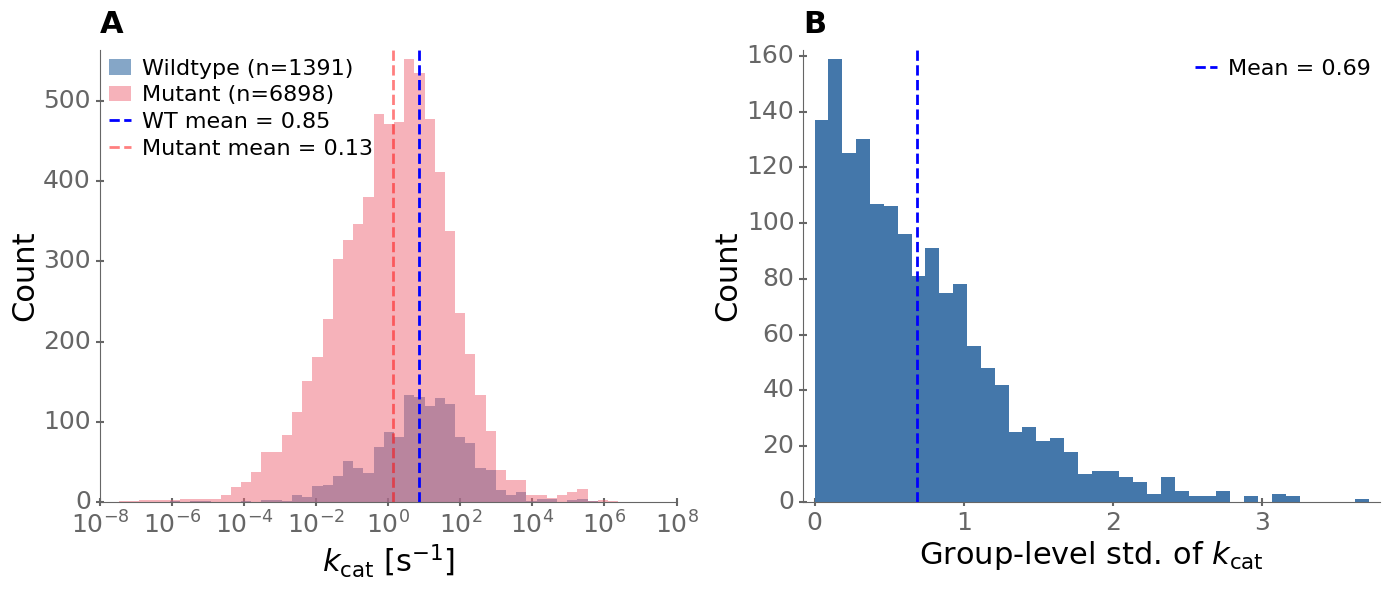

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use(Path("utils") / "CCB_plot_style_0v4.mplstyle")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

label_fontsize = 22
tick_fontsize = 18

# #A. Histogram of geom_kcat_log10 by Type 
ax = axes[0]
wt = df_kcat_all[df_kcat_all['Type'] == 'wildtype']['geom_kcat_log10'].dropna()
mut = df_kcat_all[df_kcat_all['Type'] == 'mutant']['geom_kcat_log10'].dropna()

bins = np.linspace(
    df_kcat_all['geom_kcat_log10'].min(),
    df_kcat_all['geom_kcat_log10'].max(),
    50
)

ax.hist(wt, bins=bins, alpha=0.65, label=f'Wildtype (n={len(wt)})', density=False)
ax.hist(mut, bins=bins, alpha=0.5, label=f'Mutant (n={len(mut)})', density=False)

ax.axvline(
    wt.mean(),
    linestyle='--',
    linewidth=2,
    color='blue',
    label=f'WT mean = {wt.mean():.2f}'
)
ax.axvline(
    mut.mean(),
    linestyle='--',
    alpha=0.5,
    linewidth=2,
    color='red',
    label=f'Mutant mean = {mut.mean():.2f}'
)

xmin = np.floor(df_kcat_all['geom_kcat_log10'].min())
xmax = np.ceil(df_kcat_all['geom_kcat_log10'].max())

start = 2 * np.floor(xmin / 2)
stop = 2 * np.ceil(xmax / 2)
xticks = np.arange(start, stop + 1, 2)

ax.set_xticks(xticks)
ax.set_xticklabels([rf'$10^{{{int(x)}}}$' for x in xticks])

ax.set_xlabel(r'$\mathit{k}_{\mathrm{cat}}$ [s$^{-1}$]', fontsize=label_fontsize)
ax.set_ylabel('Count', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize, length=6, width=1.5)
ax.set_title('A', loc='left', fontweight='bold', fontsize=label_fontsize)
ax.legend(fontsize=16)

## B. Distribution of std across groups (Identifier)
ax = axes[1]
std_per_group = df_kcat_all.groupby('Identifier')['geom_kcat_log10'].std().dropna()
mean_std = std_per_group.mean()

ax.hist(std_per_group, bins=40, density=False)
ax.axvline(mean_std, linestyle='--', linewidth=2, color='blue', label=f'Mean = {mean_std:.2f}')

ax.set_xlabel(r'Group-level std. of $\mathit{k}_{\mathrm{cat}}$', fontsize=label_fontsize)
ax.set_ylabel('Count', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize, length=6, width=1.5)
ax.set_title('B', loc='left', fontweight='bold', fontsize=label_fontsize)
ax.legend(fontsize=16)

plt.tight_layout()
plt.show()